In [3]:
import pandas as pd 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score 
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from scipy.stats import ttest_rel
import seaborn as sns

In [5]:
train = pd.read_csv('weather_train.csv')
test = pd.read_csv('weather_test.csv')
train = train.drop(['Unnamed: 0'], axis = 1) 
test = test.drop(['Unnamed: 0'], axis = 1)

In [7]:
train['DATE'] = pd.to_datetime(train['DATE']).dt.month
test['DATE'] = pd.to_datetime(test['DATE']).dt.month

In [9]:
# Get rid of extra test columns 
test_columns = test.columns.tolist() 
train_columns = train.columns.tolist() 

for column_name in test_columns: 
    if column_name not in train_columns: 
        test = test.drop([column_name], axis=1)

In [11]:
# Make sure the columns are in the same order 
test = test[train.columns]

In [15]:
# Classify abormal values as outliers 
columns_to_assess = ['DailyAverageDryBulbTemperature', 'DailyCoolingDegreeDays',
       'DailyDepartureFromNormalAverageTemperature', 'DailyHeatingDegreeDays',
       'DailyMaximumDryBulbTemperature', 'DailyMinimumDryBulbTemperature',
       'DailyPeakWindDirection', 'DailyPeakWindSpeed', 'DailyPrecipitation',
       'DailySnowDepth', 'DailySnowfall']

def creating_abnormal_temp(dataset, column_list):
    dataset['AbnormalTemp'] = False

    for column in column_list: 
        # Classify abnormal as outliers
        Q1 = dataset[column].quantile(0.25)
        Q3 = dataset[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Classify each value
        dataset['AbnormalTemp'] = dataset['AbnormalTemp'] | (
            (dataset[column] < lower_bound) | (dataset[column] > upper_bound)
        )

creating_abnormal_temp(train, columns_to_assess) 
creating_abnormal_temp(test, columns_to_assess) 

In [17]:
def get_city(city):
    if city == 'CHICAGO':
        return 1
    elif city == 'WINSLOW':
        return 2
    elif city == 'SAN FRANCISCO':
        return 3
    elif city == 'BOSTON':
        return 4
    elif city == 'MIAMI': 
        return 5
train['CITY'] = train['CITY'].apply(get_city)
test['CITY'] = test['CITY'].apply(get_city)

In [19]:
train_y = train['AbnormalTemp']
train_x = train.drop(['AbnormalTemp'], axis=1)
test_y = test['AbnormalTemp']
test_x = test.drop(['AbnormalTemp'], axis=1)

In [21]:
unique, counts = np.unique(train_y, return_counts=True)
print(unique)
print(counts)

[False  True]
[11786  6431]


In [23]:
unique, counts = np.unique(test_y, return_counts=True)
print(unique)
print(counts)

[False  True]
[3636 1651]


In [429]:
# Train test split 
x_train_past, x_test_past, y_train_past, y_test_past = train_test_split(train_x, train_y, test_size=0.2, random_state=1)

In [451]:
regularizations = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
train_accuracy_log = [0] * 9
test_accuracy_log = [0] * 9 
test_accuracy_present_log = [0] * 9 

train_precision_log = [0] * 9
test_precision_log = [0] * 9 
test_precision_present_log = [0] * 9 

train_recall_log = [0] * 9
test_recall_log = [0] * 9 
test_recall_present_log = [0] * 9 

train_f1score_log = [0] * 9
test_f1score_log = [0] * 9 
test_f1score_present_log = [0] * 9 


for i in range(0, len(regularizations)): 
    logistic = LogisticRegression(max_iter=10000, C=regularizations[i])
    logistic.fit(x_train_past, y_train_past) 
    log_y_pred_train = logistic.predict(x_train_past)
    log_y_pred_test = logistic.predict(x_test_past)
    log_y_pred_test_present = logistic.predict(test_x)

    # Accuracy 
    accuracy_train_log = accuracy_score(y_train_past, log_y_pred_train) 
    accuracy_test_log = accuracy_score(y_test_past, log_y_pred_test)    
    accuracy_test_present_log = accuracy_score(test_y, log_y_pred_test_present) 

    train_accuracy_log[i] = accuracy_train_log
    test_accuracy_log[i] = accuracy_test_log
    test_accuracy_present_log[i] = accuracy_test_present_log

    # Precision
    precision_train_log = precision_score(y_train_past, log_y_pred_train) 
    precision_test_log = precision_score(y_test_past, log_y_pred_test)    
    precision_test_present_log = precision_score(test_y, log_y_pred_test_present) 

    train_precision_log[i] = precision_train_log
    test_precision_log[i] = precision_test_log
    test_precision_present_log[i] = precision_test_present_log

    # Recall 
    recall_train_log = recall_score(y_train_past, log_y_pred_train) 
    recall_test_log = recall_score(y_test_past, log_y_pred_test)    
    recall_test_present_log = recall_score(test_y, log_y_pred_test_present) 

    train_recall_log[i] = recall_train_log
    test_recall_log[i] = recall_test_log
    test_recall_present_log[i] = recall_test_present_log

    # F1 Score 
    f1score_train_log = 2 * (recall_train_log * precision_train_log) / (recall_train_log + precision_train_log)
    f1score_test_log = 2 * (recall_test_log * precision_test_log) / (recall_test_log + precision_test_log) 
    f1score_test_present_log = 2 * (recall_test_present_log * precision_test_present_log) / (recall_test_present_log + precision_test_present_log) 

    train_f1score_log[i] = f1score_train_log
    test_f1score_log[i] = f1score_test_log
    test_f1score_present_log[i] = f1score_test_present_log

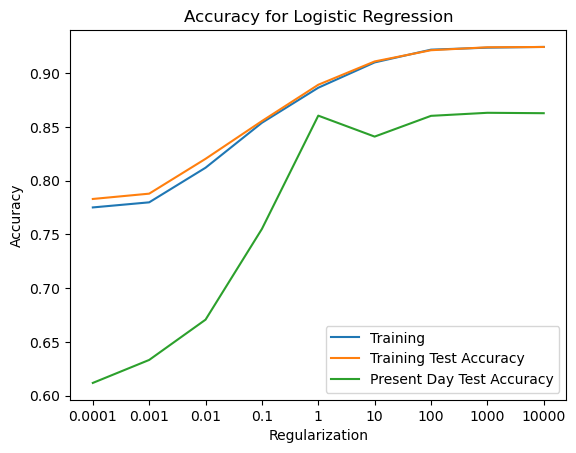

In [453]:
regularizations = ["0.0001", "0.001", "0.01", "0.1", "1", "10", "100", "1000", "10000"]
plt.plot(regularizations, train_accuracy_log, label="Training") 
plt.plot(regularizations, test_accuracy_log, label="Training Test Accuracy") 
plt.plot(regularizations, test_accuracy_present_log, label="Present Day Test Accuracy") 

plt.title("Accuracy for Logistic Regression")
plt.xlabel("Regularization")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

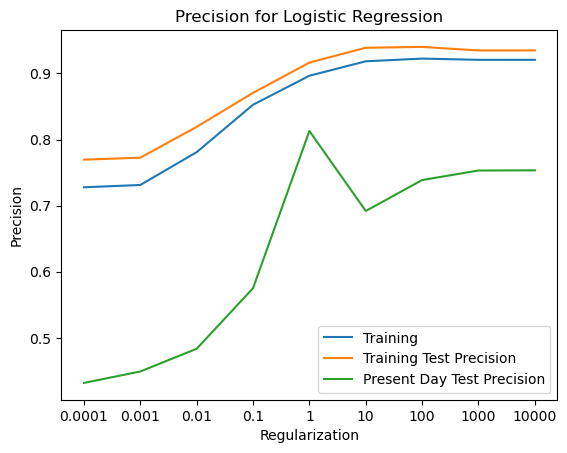

In [455]:
regularizations = ["0.0001", "0.001", "0.01", "0.1", "1", "10", "100", "1000", "10000"]
plt.plot(regularizations, train_precision_log, label="Training") 
plt.plot(regularizations, test_precision_log, label="Training Test Precision") 
plt.plot(regularizations, test_precision_present_log, label="Present Day Test Precision") 

plt.title("Precision for Logistic Regression")
plt.xlabel("Regularization")
plt.ylabel("Precision")
plt.legend()

plt.show()

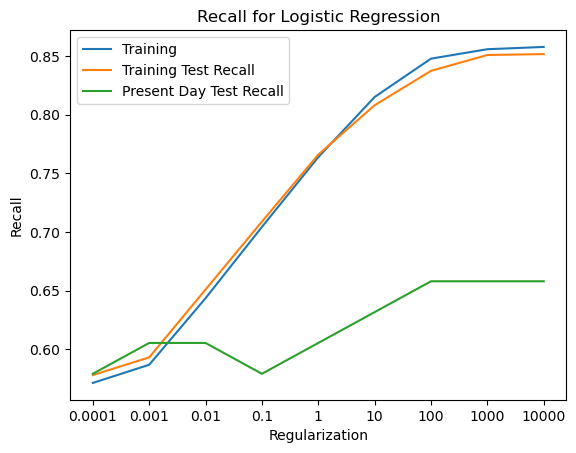

In [365]:
regularizations = ["0.0001", "0.001", "0.01", "0.1", "1", "10", "100", "1000", "10000"]
plt.plot(regularizations, train_recall_log, label="Training") 
plt.plot(regularizations, test_recall_log, label="Training Test Recall") 
plt.plot(regularizations, test_recall_present_log, label="Present Day Test Recall") 

plt.title("Recall for Logistic Regression")
plt.xlabel("Regularization")
plt.ylabel("Recall")
plt.legend()

plt.show()

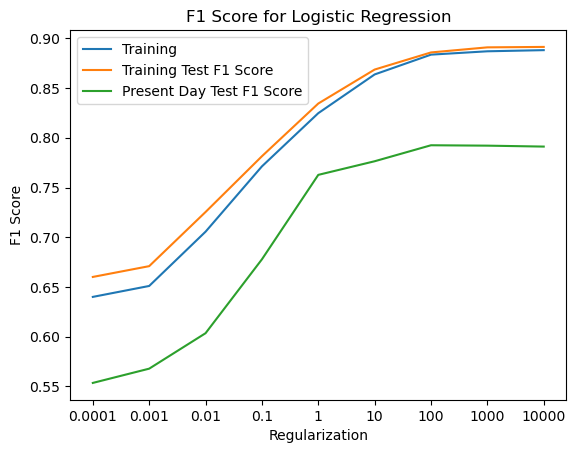

In [457]:
regularizations = ["0.0001", "0.001", "0.01", "0.1", "1", "10", "100", "1000", "10000"]
plt.plot(regularizations, train_f1score_log, label="Training") 
plt.plot(regularizations, test_f1score_log, label="Training Test F1 Score") 
plt.plot(regularizations, test_f1score_present_log, label="Present Day Test F1 Score") 

plt.title("F1 Score for Logistic Regression")
plt.xlabel("Regularization")
plt.ylabel("F1 Score")
plt.legend()

plt.show()

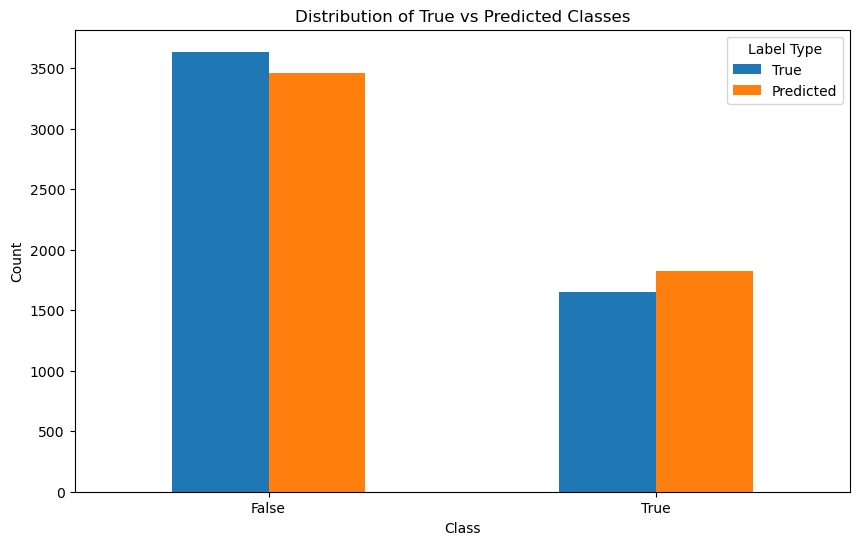

In [469]:
# Convert to Series and align on index
pred_series = pd.Series(log_y_pred_test_present, name="Predicted")
true_series = pd.Series(test_y.values, name="True")

df_compare = pd.concat([true_series.value_counts().sort_index(),
                        pred_series.value_counts().sort_index()],
                       axis=1).fillna(0)

df_compare.columns = ['True', 'Predicted']

df_compare.plot(kind='bar', figsize=(10, 6))
plt.title('Distribution of True vs Predicted Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend(title='Label Type')
plt.xticks(rotation=0)
plt.show()

Predicted a higher instance of abnormal behavior in the present day, indicating that there may be climate change trends 